### Notebook for visualizing the embeddings
- need result folder from previous notebook
- dataframe from previous notebook

In [1]:
import pandas as pd
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import umap
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Category10



In [2]:
working_dir = Path("./results")
data_name = 'data_ecoli'
assert working_dir.is_dir, f"Working directory {working_dir} does not exist."


In [3]:
data_info = pd.read_csv(working_dir / f"{data_name}.csv")
print(data_info)

                                               sequence  y   len  token_len
0     AUGAAUCAGCGUAUUCUAUCAACAUUAGGGUUUGAUAAAGUAAAAC...  0   372         84
1     AUGACGGAAAUGAAGAUUUUAAUAGUUACCCUAACUUACAUUGAAA...  0   576        129
2     AUGACGCAGCAUUUUCCGACGCGACAGCUUCGGUUCUUUCUGACGG...  0   864        178
3     AUGAGGAUUCUUGCAGAUACAAAUGUGAUAAUAGAUGCCCUGACUU...  0   444        103
4     AUGAAGCCGAUCAUCGUCUCCGAAGCCCUGCCCGGCAUCAAACUGA...  0   486         97
...                                                 ... ..   ...        ...
1495  AUGCUGCGCAUCACCGAUCAGAUCACGCUCGCCGACUGGGAACUGA...  2   450         89
1496  AUGACAGACCGUCCAUGUAGAACAGAAUUAUUAAAUCAUAUCAACG...  2   294         63
1497  AUGAACAAUCUACUAAAUAAAAUCCACCAGCAGAACGCAACUGCUU...  2  1257        274
1498  AUGAAAACACAAAUUAUUGGUGUUCUCGGUUUGGGAAUCUUUGGAC...  2   696        152
1499  AUGGGAUUGAAACUCGGAUCAAAGCCUGUUGACGGUCUUGCUCUAA...  2   675        143

[1500 rows x 4 columns]


In [6]:
data_info
print(set(data_info['y']))

{0, 1, 2}


In [4]:
from typing import Literal, Dict, List
import torch

class VizData:
    def __init__(
        self,
        working_dir: str | Path = working_dir,
        info_df: pd.DataFrame = data_info,
        choice_embedding_data: Literal["with_eos", "no_eos"] = "no_eos",
        choice_for_embedding: Literal["mean", "max", "eos"] = "mean", 
        # label_info: Dict = {'plant':0 ,'bacteria':1,'invertebrate':2,'fungi':3},
        label_info: Dict = {'Low':0 ,'Medium':1,'High':2},
       ):

        assert working_dir.is_dir(), f"Working directory {working_dir} does not exist."

        self.info = info_df
        self.labels = info_df["y"].values
        self.label_info = label_info
        self.reverse_label_info = {v: k for k, v in label_info.items()}

        self.choice_embedding_data = choice_embedding_data
        self.choice_for_embedding = choice_for_embedding

        self.umap_df = pd.DataFrame()
        self.umap_df["labels"] = self.labels

        # use bokeh color palette
        # self.palette = Category10[10]
        # choose 5 colors for the 5 classes

        # use user def colors
        colors = ['red','blue','green'] #, 'red', 'green', 'brown','pink','yellow']
        markers = ['circle', 'square', 'triangle']
        sizes = [10, 10, 12, 14]
        self.umap_df['color'] = self.umap_df['labels'].map(lambda x: colors[x])
        self.umap_df['marker'] = self.umap_df['labels'].map(lambda x: markers[x])
        self.umap_df['legend'] = self.umap_df['labels'].map(self.reverse_label_info)
        self.umap_df['size'] = self.umap_df['labels'].map(lambda x: sizes[x])
        
        self.embedding_data = self.get_embedding_data(choice_embedding_data)
        self.embeddings = self.get_embedding(choice_for_embedding, self.embedding_data)

        print(f"Loaded {self.choice_embedding_data} embedding with shape {self.embeddings.shape}.")

    @staticmethod
    def get_embedding_data(choice):
        match choice:
            case "with_eos":
                embedding_data = torch.load(working_dir / f"ecoli_emb_with_eos.pt")
            case "no_eos":
                embedding_data = torch.load(working_dir / f"ecoli_emb_no_eos.pt") 
                # embedding_data = torch.load("state_embeddings_no_eos.pt").to("cpu") 

            case _:
                raise ValueError("Invalid choice for embedding data. Choose 'with_eos' or 'no_eos'.")
            
        return embedding_data 

    @staticmethod
    def get_embedding(choice, embedding_data):
        match choice:
            case "mean":
                embeddings = embedding_data.mean(dim=1)
            case "max":
                embeddings = embedding_data.max(dim=1) 

            case _:


                raise ValueError("Invalid choice for embedding. Choose 'mean', 'max', or 'eos'.")
        return embeddings
    

In [5]:
viz = VizData(
    working_dir=working_dir,
    info_df=data_info,
    choice_embedding_data="with_eos",
    choice_for_embedding="mean",
)
 
    

Loaded with_eos embedding with shape torch.Size([1500, 768]).


/tmp/ipykernel_3659268/2922994618.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embedding_data = torch.load(working_dir / f"ecoli_emb_with_eos.pt")


In [6]:
viz.embeddings
print(viz.embeddings.shape)

torch.Size([1500, 768])


In [7]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import umap
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Category10
# from bokeh.plotting import figure, output_file, save
from bokeh.io import export_png
from sklearn.preprocessing import StandardScaler, MinMaxScaler

output_notebook()

# # Step 3: PCA
pca = PCA(n_components=70)
pca_embeddings = pca.fit_transform(viz.embeddings)

# Step 4: UMAP
# umap_model = umap.UMAP(
#     n_neighbors=20,
#     n_epochs=1000,
#     min_dist=0.0,
#     init='random',
#     repulsion_strength=0,
#     metric = 'manhattan',
#     random_state=42,
#     # local_connectivity=2.0
#     spread=0.4
# )

umap_model = umap.UMAP(
    n_neighbors=20,
    n_epochs=1500,
    min_dist=1.0,
    init='spectral',
    repulsion_strength=0,
    # metric='euclidean',
    metric = 'manhattan',
    n_components=2,
    random_state=42,
    spread=1.0
)
# umap_embeddings = umap_model.fit_transform(pca_embeddings)
# umap_embeddings = umap_model.fit_transform(normalized_embeddings)
umap_embeddings = umap_model.fit_transform(viz.embeddings)

umap_df = viz.umap_df

# add umap embeddings to the dataframe
umap_df["x"] = umap_embeddings[:, 0]
umap_df["y"] = umap_embeddings[:, 1]
# Map colors to labels

# Step 5: Create Bokeh plot with tooltips
source = ColumnDataSource(umap_df)

hover = HoverTool(tooltips=[
    # ("Index", "@index"),
    # ("Label", "@label"),
    ("Label", "@legend"),
    ('Marker', '@marker'),
    ('Size','@size'),
    # ("x", "@x{0.2f}"),
    # ("y", "@y{0.2f}")
])


plot = figure(
    title="UMAP for RNA CodonBERT Embeddings",
    
    tools=["pan,wheel_zoom,reset", hover],
    width=700, height=600
)
# 플롯의 전체 테두리 설정
plot.outline_line_color = "black"
plot.outline_line_width = 2

plot.scatter(
    'x', 'y', 
    source=source, 
    color='color',
    marker = 'marker',
    size= 'size',
    legend_field='legend',
    alpha=0.8,
    line_color = 'white',
    line_width = 1.5
)
plot.xaxis.axis_label = 'UMAP Dimension 1'
plot.yaxis.axis_label = 'UMAP Dimension 2'
plot.legend.location = 'bottom_right'
# x축과 y축의 눈금 및 숫자 제거
plot.xaxis.visible = False
plot.yaxis.visible = False
plot.xgrid.visible = False
plot.ygrid.visible = False
# filename = 'embedding_1.html'
# output_file(filename=f"{filename}", title="")
# export_png(plot, filename = filename)
show(plot)
# save(plot)



Loading BokehJS ...

/fsx/home/jhhong/miniconda3/envs/rna/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/fsx/home/jhhong/miniconda3/envs/rna/lib/python3.12/site-packages/umap/umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
/fsx/home/jhhong/miniconda3/envs/rna/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/fsx/home/jhhong/miniconda3/envs/rna/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


<Figure size 1000x800 with 0 Axes>

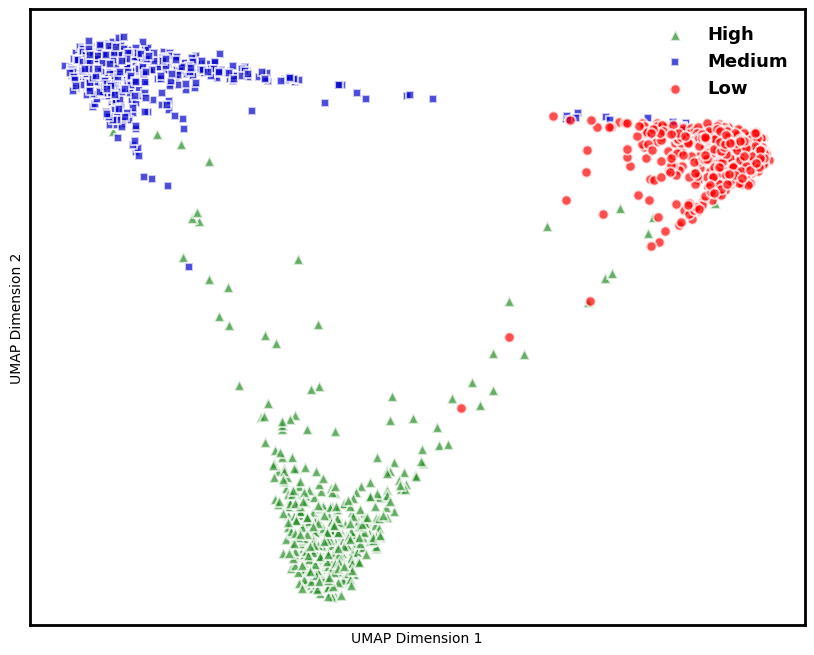

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import umap

pca = PCA(n_components=100)
pca_embeddings = pca.fit_transform(viz.embeddings)

# umap_model = umap.UMAP(
#     n_neighbors=20,
#     n_epochs=1500,
#     min_dist=0.0,
#     init='spectral',
#     repulsion_strength=4,
#     # metric='euclidean',
#     metric = 'manhattan',
#     # n_components=2,
#     random_state=42,
# # spread=0.3
# )
# umap_model = umap.UMAP(
#     n_neighbors=2,
#     n_epochs=1500,
#     min_dist=0.5,
#     init='spectral',
#     repulsion_strength=1.0,
#     metric='euclidean',
#     # metric = 'manhattan',
#     n_components=2,
#     random_state=42,
#     spread=0.9
# )

umap_model = umap.UMAP(
    n_neighbors=2,
    n_epochs=1500,
    # min_dist=4.0,
    # init='spectral',
    repulsion_strength=0.0,
    # metric='hamming',
    # metric = 'manhattan',
    # n_components=10,
    random_state=42,
    spread=10.0
)
# umap_embedding = umap_model.fit_transform(viz.embeddings)
umap_embedding = umap_model.fit_transform(pca_embeddings)
umap_df = viz.umap_df
# print(umap_df)

# add umap embeddings to the dataframe
umap_df["x"] = umap_embeddings[:, 0]
umap_df["y"] = umap_embeddings[:, 1]
# Map colors to labels

plt.figure(figsize=(10, 8))
# 클러스터별 마커 설정
markers_palette = {
    'High' :'^', 
    'Medium':'s', 
    'Low' :'o'}
    # fungi' :'+'}
unique_labels = umap_df['labels'].unique()

# 플롯 생성
plt.figure(figsize=(10, 8))
# 사용자 정의 색상 팔레트
custom_palette = {
    'High' : 'forestgreen',
    'Medium': 'mediumblue',
    'Low' : 'red',}
    # 'high': 'forestgreen',
    # 'fungi': 'green'
# }
size_palette = {
    'High': 60,
    'Medium': 40,
    'Low' : 55,
}
# 각 클러스터에 대해 개별적으로 scatter plot 생성
for label in custom_palette.keys():
    subset = umap_df[umap_df['legend'] == label]
    plt.scatter(subset['x'], subset['y'], 
                label=label, 
                color=custom_palette[label], 
                marker=markers_palette[label], 
                alpha=0.7, 
                s=size_palette[label], 
                edgecolor='white', 
                linewidth=1.5)


plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend( loc='best', fontsize='medium')
# x축과 y축의 눈금 없애기
plt.xticks([])  # x축 눈금 없애기
plt.yticks([])  # y축 눈금 없애기

# 그래프 테두리 설정
plt.gca().spines['top'].set_linewidth(2)
plt.gca().spines['right'].set_linewidth(2)
plt.gca().spines['left'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)

filename = './Embedding_space_data/ecoli_embedding_plot.png'
plt.legend(prop={'size':13,'weight':'bold'},frameon=False)
plt.savefig(filename, dpi=300)  # 해상도를 300 DPI로 설정하여 저장

# 플롯 표시
plt.show()